# Jena Climate data exploration

This notebook downloads the real Jena Climate archive on first use, converts the 10-minute observations to hourly readings, and examines the signals used by the forecasters.

In [1]:
import sys
sys.path.append('..')
import matplotlib.pyplot as plt
import pandas as pd
from scripts.train import TARGETS, load_hourly_data
plt.style.use('seaborn-v0_8-whitegrid')
frame, features = load_hourly_data('../data')
frame.shape, len(features), TARGETS

((70092, 15), 14, ['T (degC)', 'rh (%)'])

In [2]:
frame[['Date Time'] + TARGETS].describe().T
print('Hourly rows:', len(frame))
print('Date range:', frame['Date Time'].min(), 'to', frame['Date Time'].max())
print('Missing values (after source sentinel handling):')
frame[features].replace(-9999, float('nan')).isna().sum().sort_values(ascending=False).head()

Hourly rows: 70092
Date range: 2009-01-01 00:10:00 to 2016-12-31 23:20:00
Missing values (after source sentinel handling):


max. wv (m/s)    4
wv (m/s)         3
Tpot (K)         0
Tdew (degC)      0
p (mbar)         0
dtype: int64

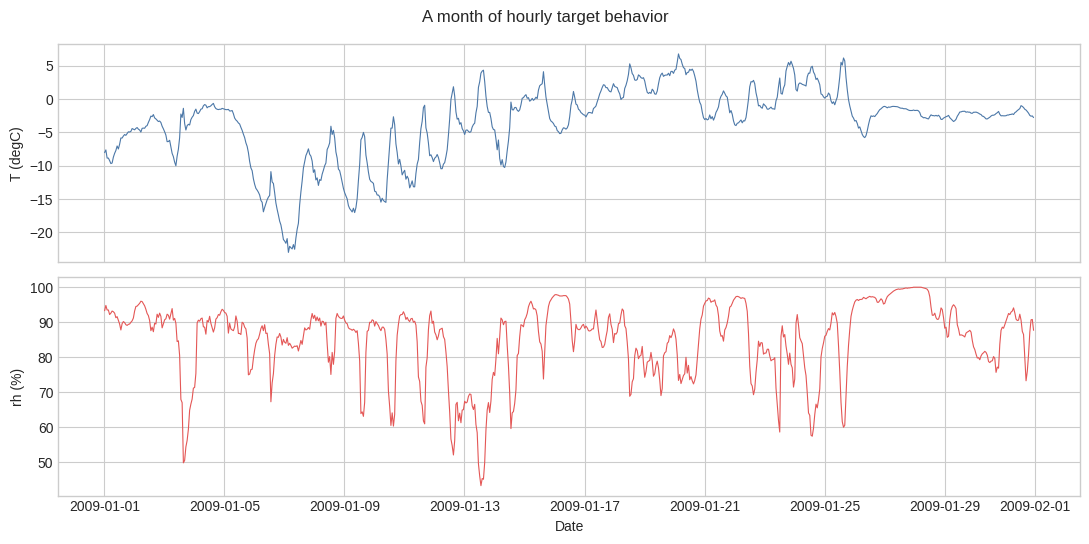

In [3]:
month = frame.iloc[:24 * 31]
fig, axes = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)
for axis, target, color in zip(axes, TARGETS, ['#4C78A8', '#E45756']):
    axis.plot(month['Date Time'], month[target], color=color, linewidth=.8)
    axis.set_ylabel(target)
axes[-1].set_xlabel('Date')
fig.suptitle('A month of hourly target behavior'); fig.tight_layout()

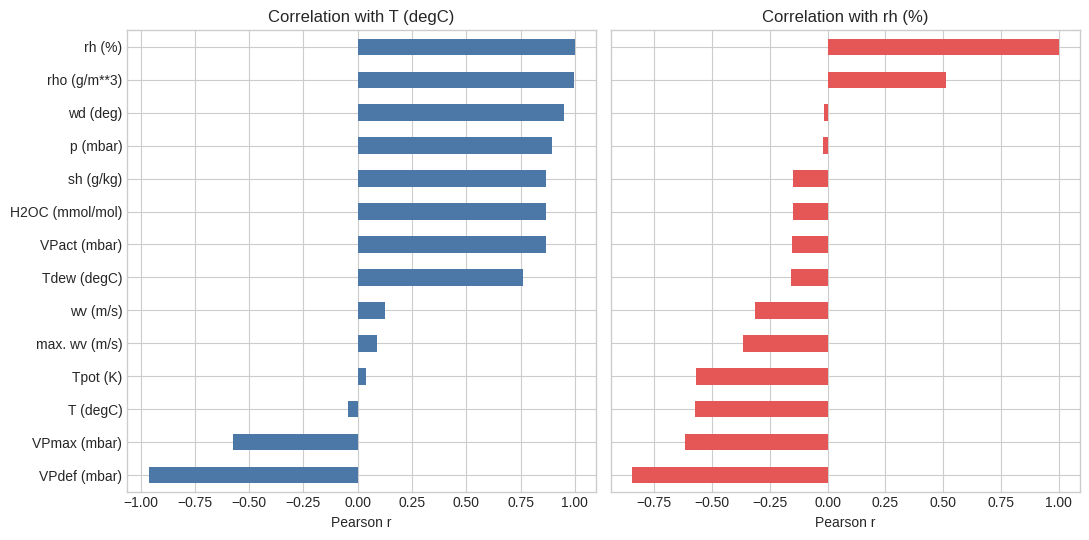

In [4]:
corr = frame[features].replace(-9999, float('nan')).corr()[TARGETS]
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5), sharey=True)
for axis, target, color in zip(axes, TARGETS, ['#4C78A8', '#E45756']):
    corr[target].sort_values().plot.barh(ax=axis, color=color)
    axis.set_title(f'Correlation with {target}'); axis.set_xlabel('Pearson r')
fig.tight_layout()

## Windowing decision

Each training example uses the preceding **72 hourly readings** from all 14 sensors. The models produce the next 72 temperature and humidity values, and are evaluated at 6, 24, and 72 hours ahead. Data are split chronologically (70%/15%/15%) and are standardized from training statistics only.